# Week 3-1 Sigle Neuron Architecture

## 1. Prediction

### 1.1 Single Input

In [1]:
# An empty network
def neural_network(input, weight):
  prediction = input * weight
  return prediction

In [2]:
weight = 0.1

plant_states = [320, 160, 8.5, 255, 1, 100]
input = plant_states[2]
pred = neural_network(input, weight)

print(f'Input : {input} -> Net -> Pred : {pred}')

Input : 8.5 -> Net -> Pred : 0.8500000000000001


### 1.2 Multi Inputs

In [3]:
# An empty network
def neural_network_multi_inputs(inputs, weights):
  assert(len(inputs) == len(weights)) # Check input sizes

  output = 0

  for i in range(len(inputs)):
    o = inputs[i] * weights[i]
    output += o

    print(f'{i} : {inputs[i]}*{weights[i]}={o}')
  return output

In [4]:
weights = [0.1, 0.2, 0]
plant_states = [8.5, 320, 160]

neural_network_multi_inputs(plant_states, weights)

0 : 8.5*0.1=0.8500000000000001
1 : 320*0.2=64.0
2 : 160*0=0


64.85

### 1.3 Single Input -> Multiple Outputs

In [5]:
# An empty network
def neural_network_multi_outputs(input, weights):
  outputs = [0 for _ in range(len(weights))] # initial output size

  for i in range(len(outputs)):
    outputs[i] = input * weights[i]

    print(f'{i} : {input}*{weights[i]}={outputs[i]}')
  return outputs

In [6]:
weights = [0.3, 0.2, 0.9]
plant_states = 0.65

neural_network_multi_outputs(plant_states, weights)

0 : 0.65*0.3=0.195
1 : 0.65*0.2=0.13
2 : 0.65*0.9=0.5850000000000001


[0.195, 0.13, 0.5850000000000001]

### 1.4 Multiple inputs & outputs

In [7]:
def neural_network(input, weights):
  # weights sum
  def w_sum(a,b):
    assert(len(a) == len(b))
    output = 0
    output_txt = ''
    for i in range(len(a)):
      output += (a[i] * b[i])
      output_txt += f'[{a[i]}*{b[i]}={a[i] * b[i]}]'
    return output, output_txt

  # vector
  def vect_mat_mul(vect,matrix):
    output = [0 for _ in range(len(matrix))] # initial output size
    for i in range(len(vect)):
      output[i], Otxt = w_sum(vect, matrix[i])
      print(f'Output [{i}] {output[i]} = {Otxt}')
    return output

  pred = vect_mat_mul(input,weights)

  return pred

In [8]:
weights = [
  [0.13, 0.12, 0.3],
  [0.11, 0.2, 0.0],
  [0.0, 1.3, 0.15]]
plant_states = [8.5, 320, 160]

neural_network(plant_states, weights)

Output [0] 87.505 = [8.5*0.13=1.105][320*0.12=38.4][160*0.3=48.0]
Output [1] 64.935 = [8.5*0.11=0.935][320*0.2=64.0][160*0.0=0.0]
Output [2] 440.0 = [8.5*0.0=0.0][320*1.3=416.0][160*0.15=24.0]


[87.505, 64.935, 440.0]

### 1.5 Vector-Matrix Multiplication(Numpy)

In [9]:
import numpy as np
inputs = np.array([8.5, 320, 160])
weights = np.array(
    [[0.13, 0.11, 0.0],
     [0.12, 0.2, 1.3],
     [0.3, 0.0, 0.15]])

np.dot(inputs, weights)

array([ 87.505,  64.935, 440.   ])

### 1.6 Stacked Neural Network

In [10]:
def neural_network(inputs, h1_weights, o_weights):
  hid_out = np.dot(inputs, h1_weights)
  print(hid_out)
  pred = np.dot(hid_out, o_weights)
  print(pred)
  return pred

In [11]:
inputs = np.array([8.5, 320, 160])
h1_weights = np.array(
    [[0.13, 0.11, 0.0],
     [0.12, 0.2, 1.3],
     [0.3, 0.0, 0.15]])
o_weights = np.array(
    [[0.3, 0.4, 0.6],
     [0.2, 0.5, 0.4],
     [0.4, 0.2, 0.7]])
neural_network(inputs, h1_weights, o_weights)

[ 87.505  64.935 440.   ]
[215.2385 155.4695 386.477 ]


array([215.2385, 155.4695, 386.477 ])

In [12]:
import numpy as np

def linear(in_features, out_features, bias=True):
    """
    Generalized structure for a Linear Transformation Layer.
    in_features: Number of input features (e.g., sensors).
    out_features: Number of output features (e.g., diagnostic targets).
    """

    # 1. Initialize Weight Matrix (Shape: out_features x in_features)
    # This represents the 'knowledge' each output node has about all inputs.
    weights = np.random.randn(out_features, in_features) * 0.01

    # 2. Initialize Bias Vector
    # A correction term that allows the model to adapt flexibly even when inputs are zero.
    b = np.zeros(out_features) if bias else None

    def forward(inputs):
        """
        Perform the Forward Pass using Vector-Matrix Multiplication.
        """
        # Calculate Weighted Sum by performing a dot product with transposed weights.
        # Transposing aligns the shapes correctly: (inputs) dot (weights.T).
        pred = np.dot(inputs, weights.T)

        # Add bias if it is enabled.
        if b is not None:
            pred += b

        return pred

    return forward

In [13]:
# 발전소 실시간 데이터 (Flow, Temp, Pres)
current_sensors = np.array([8.5, 320, 160])

# 3개의 입력을 받아 3개의 출력을 내는 선형 층 생성
diagnostic_layer = linear(in_features=3, out_features=3)

# 진단 실행
results = diagnostic_layer(current_sensors)

print("--- 발전소 기기 진단 결과 ---")
print(f"입력 데이터: {current_sensors}")
print(f"진단 벡터 (Valve A, Pump B, Rod Pos): {results}")

--- 발전소 기기 진단 결과 ---
입력 데이터: [  8.5 320.  160. ]
진단 벡터 (Valve A, Pump B, Rod Pos): [ 0.71426111 -0.09065657  2.28155507]


# Week 3-2 Simple Loss Function & Gradient Descent

## 2. Introduction to neural learning


### 2.1 Hot-and-cold Method (Single)

In [ ]:
# Network
def NN(input, w, target_output):
  return (input * w - target_output) ** 2

Temp = 100
W = 0.1
Target_State = 1

# 1. Predict
err = NN(Temp, W, Target_State)
print(f'Loop 1 : Step1 : W {W:.2f}, Err {err:.2f}')

Loop 1 : Step1 : W 0.10, Err 81.00


In [ ]:
# 2. Compare
lr = 0.05
W_new = W + lr
err = NN(Temp, W_new, Target_State)
print(f'Loop 1 : Step2 : W {W_new:.2f}, Err {err:.2f}')

Loop 1 : Step2 : W 0.15, Err 196.00


In [ ]:
# 3. Compare
lr = -0.15
W_new = W_new + lr
err = NN(Temp, W_new, Target_State)
print(f'Loop 1 : Step3 : W {W_new:.2f}, Err {err:.2f}')

Loop 1 : Step3 : W 0.00, Err 1.00


Loop 0 : W 0.10000, Err 81.00000
Loop 1 : W 0.08000, Err 49.00000
Loop 2 : W 0.06000, Err 25.00000
Loop 3 : W 0.04000, Err 9.00000
Loop 4 : W 0.02000, Err 1.00000


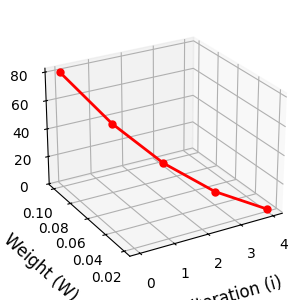

In [ ]:
import matplotlib.pyplot as plt

# Network
def NN(input, w, target_output):
  return (input * w - target_output) ** 2

Temp = 100
W = 0.1
lr = 0.02
Target_State = 1

history_i = []
history_w = []
history_err = []

for i in range(5):
  # Predict & Compare
  err = NN(Temp, W, Target_State)
  print(f'Loop {i} : W {W:.5f}, Err {err:.5f}')
  history_i.append(i)
  history_w.append(W)
  history_err.append(err)

  # 2. Learning
  # Predict [Up]
  err_up = NN(Temp, W + lr, Target_State)
  # Predict [Down]
  err_down = NN(Temp, W - lr, Target_State)
  # Update W
  if err_down < err:
      W -= lr
  if err_up < err:
      W += lr

# 3D Plot
fig = plt.figure(figsize=(3, 3))
ax = fig.add_subplot(111, projection='3d')

ax.plot(history_i, history_w, history_err, 'r-o', markersize=5, label='Learning Path', linewidth=2, zorder=5)
ax.set_xlabel('Iteration (i)', fontsize=12, labelpad=10)
ax.set_ylabel('Weight (W)', fontsize=12, labelpad=10)
ax.set_zlabel('Error (Err)', fontsize=12, labelpad=10)
ax.view_init(elev=25, azim=-120)
plt.tight_layout()
plt.show()

### 2.2 Gradient Descent (Single)

Loop  0 : Pred 0.00000, W 0.00000, Err 0.64000 Delta_W -0.88000
Loop  1 : Pred 0.96800, W 0.88000, Err 0.02822 Delta_W 0.18480
Loop  2 : Pred 0.76472, W 0.69520, Err 0.00124 Delta_W -0.03881
Loop  3 : Pred 0.80741, W 0.73401, Err 0.00005 Delta_W 0.00815
Loop  4 : Pred 0.79844, W 0.72586, Err 0.00000 Delta_W -0.00171
Loop  5 : Pred 0.80033, W 0.72757, Err 0.00000 Delta_W 0.00036
Loop  6 : Pred 0.79993, W 0.72721, Err 0.00000 Delta_W -0.00008
Loop  7 : Pred 0.80001, W 0.72729, Err 0.00000 Delta_W 0.00002
Loop  8 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W -0.00000
Loop  9 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W 0.00000
Loop 10 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W -0.00000
Loop 11 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W 0.00000
Loop 12 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W -0.00000
Loop 13 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W 0.00000
Loop 14 : Pred 0.80000, W 0.72727, Err 0.00000 Delta_W -0.00000
Loop 15 : Pred 0.80000, W 0.72727, Err 0.00000 

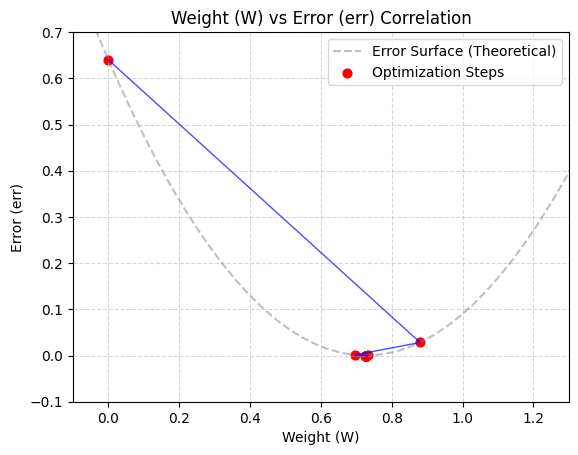

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Network
def NN(input, w): return input * w

Flow = 1.1
W = 0.0
Target_State = 0.8

w_history = []
err_history = []

for i in range(20):
  # 1. Predict
  pred = NN(Flow, W)
  err = (pred - Target_State) ** 2

  # 2. Learning
  direction_and_amount = (pred - Target_State) * Flow
  print(f'Loop {i:2} : Pred {pred:.5f}, W {W:.5f}, Err {err:.5f} Delta_W {direction_and_amount:.5f}')

  w_history.append(W)
  err_history.append(err)

  W = W - direction_and_amount

w_range = np.linspace(-0.2, 3.5, 100)
err_curve = (Flow * w_range - Target_State)**2

# Plotting
plt.plot(w_range, err_curve, color='gray', linestyle='--', alpha=0.5, label='Error Surface (Theoretical)')
plt.scatter(w_history, err_history, color='red', s=40, label='Optimization Steps')
plt.plot(w_history, err_history, color='blue', linewidth=1, alpha=0.7)
plt.xlim(-0.1, 1.3)
plt.ylim(-0.1, 0.7)

# Annotate the start and end
plt.title('Weight (W) vs Error (err) Correlation')
plt.xlabel('Weight (W)')
plt.ylabel('Error (err)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

### 2.2 Gradient Descent (Divergence)

Loop  0 : Pred 1.00000, W 0.50000, Err 0.04000 Delta_W 0.40000
Loop  1 : Pred 0.20000, W 0.10000, Err 0.36000 Delta_W -1.20000
Loop  2 : Pred 2.60000, W 1.30000, Err 3.24000 Delta_W 3.60000
Loop  3 : Pred -4.60000, W -2.30000, Err 29.16000 Delta_W -10.80000
Loop  4 : Pred 17.00000, W 8.50000, Err 262.44000 Delta_W 32.40000
Loop  5 : Pred -47.80000, W -23.90000, Err 2361.96000 Delta_W -97.20000
Loop  6 : Pred 146.60000, W 73.30000, Err 21257.64000 Delta_W 291.60000
Loop  7 : Pred -436.60000, W -218.30000, Err 191318.76000 Delta_W -874.80000
Loop  8 : Pred 1313.00000, W 656.50000, Err 1721868.84000 Delta_W 2624.40000
Loop  9 : Pred -3935.80000, W -1967.90000, Err 15496819.56000 Delta_W -7873.20000
Loop 10 : Pred 11810.60000, W 5905.30000, Err 139471376.04000 Delta_W 23619.60000
Loop 11 : Pred -35428.60000, W -17714.30000, Err 1255242384.36000 Delta_W -70858.80000
Loop 12 : Pred 106289.00000, W 53144.50000, Err 11297181459.24000 Delta_W 212576.40000
Loop 13 : Pred -318863.80000, W -159431

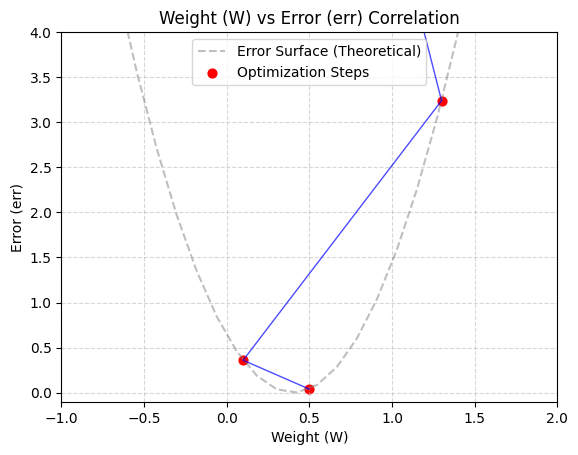

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Network
def NN(input, w): return input * w

Flow = 2.0
W = 0.5
Target_State = 0.8

w_history = []
err_history = []

for i in range(20):
  # 1. Predict
  pred = NN(Flow, W)
  err = (pred - Target_State) ** 2

  # 2. Learning
  direction_and_amount = (pred - Target_State) * Flow
  print(f'Loop {i:2} : Pred {pred:.5f}, W {W:.5f}, Err {err:.5f} Delta_W {direction_and_amount:.5f}')

  w_history.append(W)
  err_history.append(err)

  W = W - direction_and_amount

w_range = np.linspace(-2.0, 10, 100)
err_curve = (Flow * w_range - Target_State)**2

# Plotting
plt.plot(w_range, err_curve, color='gray', linestyle='--', alpha=0.5, label='Error Surface (Theoretical)')
plt.scatter(w_history, err_history, color='red', s=40, label='Optimization Steps')
plt.plot(w_history, err_history, color='blue', linewidth=1, alpha=0.7)
plt.xlim(-1.0, 2.0)
plt.ylim(-0.1, 4)

# Annotate the start and end
plt.title('Weight (W) vs Error (err) Correlation')
plt.xlabel('Weight (W)')
plt.ylabel('Error (err)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

### 2.3 Alpha

Loop  0 : Pred 1.00000, W 0.50000, Err 0.04000 Delta_W 0.40000
Loop  1 : Pred 0.92000, W 0.46000, Err 0.01440 Delta_W 0.24000
Loop  2 : Pred 0.87200, W 0.43600, Err 0.00518 Delta_W 0.14400
Loop  3 : Pred 0.84320, W 0.42160, Err 0.00187 Delta_W 0.08640
Loop  4 : Pred 0.82592, W 0.41296, Err 0.00067 Delta_W 0.05184
Loop  5 : Pred 0.81555, W 0.40778, Err 0.00024 Delta_W 0.03110
Loop  6 : Pred 0.80933, W 0.40467, Err 0.00009 Delta_W 0.01866
Loop  7 : Pred 0.80560, W 0.40280, Err 0.00003 Delta_W 0.01120
Loop  8 : Pred 0.80336, W 0.40168, Err 0.00001 Delta_W 0.00672
Loop  9 : Pred 0.80202, W 0.40101, Err 0.00000 Delta_W 0.00403
Loop 10 : Pred 0.80121, W 0.40060, Err 0.00000 Delta_W 0.00242
Loop 11 : Pred 0.80073, W 0.40036, Err 0.00000 Delta_W 0.00145
Loop 12 : Pred 0.80044, W 0.40022, Err 0.00000 Delta_W 0.00087
Loop 13 : Pred 0.80026, W 0.40013, Err 0.00000 Delta_W 0.00052
Loop 14 : Pred 0.80016, W 0.40008, Err 0.00000 Delta_W 0.00031
Loop 15 : Pred 0.80009, W 0.40005, Err 0.00000 Delta_W 

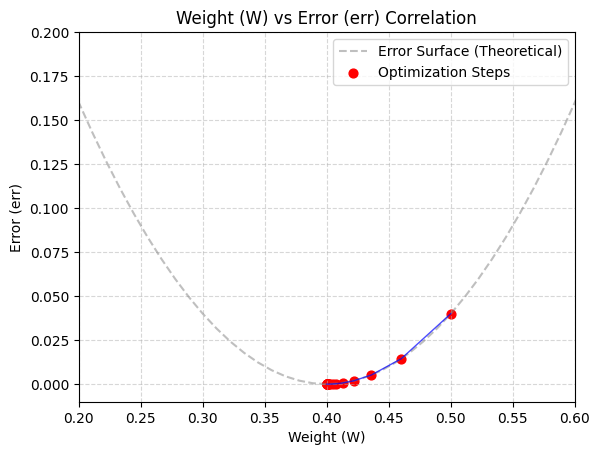

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Network
def NN(input, w): return input * w

Flow = 2.0
W = 0.5
a = 0.1
Target_State = 0.8

w_history = []
err_history = []

for i in range(20):
  # 1. Predict
  pred = NN(Flow, W)
  err = (pred - Target_State) ** 2

  # 2. Learning
  direction_and_amount = (pred - Target_State) * Flow
  print(f'Loop {i:2} : Pred {pred:.5f}, W {W:.5f}, Err {err:.5f} Delta_W {direction_and_amount:.5f}')

  w_history.append(W)
  err_history.append(err)

  W = W - a * direction_and_amount

w_range = np.linspace(-0.1, 1, 100)
err_curve = (Flow * w_range - Target_State)**2

# Plotting
plt.plot(w_range, err_curve, color='gray', linestyle='--', alpha=0.5, label='Error Surface (Theoretical)')
plt.scatter(w_history, err_history, color='red', s=40, label='Optimization Steps')
plt.plot(w_history, err_history, color='blue', linewidth=1, alpha=0.7)
plt.xlim(0.2, 0.6)
plt.ylim(-0.01, 0.2)

# Annotate the start and end
plt.title('Weight (W) vs Error (err) Correlation')
plt.xlabel('Weight (W)')
plt.ylabel('Error (err)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

## 3. Learning multiple weights at a time

### 3.1 Gradient descent learning with multiple inputs

In [ ]:
import numpy as np
def neural_network(inputs, weights): return np.dot(inputs, weights)

w = [0.1, 0.2, -0.1]
flow = 8.5
temp = 0.65
pres = 1.2
pump = 1

pred = neural_network([flow, temp, pres], w)
erro = (pred - pump) ** 2
delt = pred - pump
print(f'Pred:{pred:.2f}|Erro:{erro:.2f}|Delt:{delt:.2f}')

Pred:0.86|Erro:0.02|Delt:-0.14


In [ ]:
def ele_mul(delta, inputs): # element-wise multiplication
  return [delta * inputs[i] for i in range(len(inputs))]
weight_delta = ele_mul(delt, [flow, temp, pres])
print(f'DW1:{weight_delta[0]:.3f}, DW2:{weight_delta[1]:.3f}, DW3:{weight_delta[2]:.3f}')

DW1:-1.190, DW2:-0.091, DW3:-0.168


In [ ]:
alpha = 0.01
print(f'Old W : {w[0]:.3f}, {w[1]:.3f}, {w[2]:.3f}')
for i in range(len(w)):
  w[i] -= alpha * weight_delta[i]
print(f'New W : {w[0]:.3f}, {w[1]:.3f}, {w[2]:.3f}')

Old W : 0.100, 0.200, -0.100
New W : 0.112, 0.201, -0.098


In [ ]:
pred = neural_network([flow, temp, pres], w)
erro = (pred - pump) ** 2
delt = pred - pump
print(f'Pred:{pred:.2f}|Erro:{erro:.2f}|Delt:{delt:.2f}')

Pred:0.96|Erro:0.00|Delt:-0.04


### 3.2 Gradient descent learning with multiple outputs

In [ ]:
def ele_mul(delta, inputs): # element-wise multiplication
  return [delta * inputs[i] for i in range(len(inputs))]
def neural_network(inputs, weights): return ele_mul(inputs, weights)

w = [0.3, 0.2, 0.9]

temp = 0.65
valveA = 0.1
pumpB = 1.0
rodpos = 0.1

pred = neural_network(temp, w)
print(pred)

[0.195, 0.13, 0.5850000000000001]


In [ ]:
true = [valveA, pumpB, rodpos]
error = [0, 0, 0]
delta = [0, 0, 0]
for i in range(len(true)):
  error[i] = (pred[i] - true[i]) ** 2
  delta[i] = pred[i] - true[i]
print(f'D_1:{delta[0]:.3f}, D_2:{delta[1]:.3f}, D_3:{delta[2]:.3f}')
print(f'E_1:{error[0]:.3f}, E_2:{error[1]:.3f}, E_3:{error[2]:.3f}')

def scalar_ele_mul(number,vector):
  return [number * vector[i] for i in range(len(vector))]
weight_deltas = scalar_ele_mul(temp, delta)
print(f'DW1:{weight_deltas[0]:.3f}, DW2:{weight_deltas[1]:.3f}, DW3:{weight_deltas[2]:.3f}')

D_1:0.095, D_2:-0.870, D_3:0.485
E_1:0.009, E_2:0.757, E_3:0.235
DW1:0.062, DW2:-0.566, DW3:0.315


In [ ]:
alpha = 0.01
print(f'Old W : {w[0]:.3f}, {w[1]:.3f}, {w[2]:.3f}')
for i in range(len(w)):
  w[i] -= alpha * weight_deltas[i]
print(f'New W : {w[0]:.3f}, {w[1]:.3f}, {w[2]:.3f}')

Old W : 0.300, 0.200, 0.900
New W : 0.299, 0.206, 0.897


### 3.3 Gradient descent with multiple inputs and outputs

In [ ]:
def w_sum(a,b): return sum([a[i] * b[i] for i in range(len(a))])
def vect_mat_mul(vect,matrix):
  return [w_sum(vect, matrix[i]) for i in range(len(vect))]
def neural_network(input, weights):
  return vect_mat_mul(input,weights)

w = [
  [0.1, 0.1, -0.3],
  [0.1, 0.2, 0.0],
  [0.0, 1.3, 0.1]]
flow, temp, pres = 8.5, 0.65, 1.2     # input
valveA, pumpB, rodpos = 0.1, 1.0, 0.1 # output(true)
# 1. Making a prediction
pred = neural_network([flow, temp, pres], w)
print(f'PR1:{pred[0]:.3f}, PR2:{pred[1]:.3f}, PR3:{pred[2]:.3f}')
# 2. Calculating error and delta
true = [valveA, pumpB, rodpos]
error = [0, 0, 0]
delta = [0, 0, 0]
for i in range(len(true)):
  error[i] = (pred[i] - true[i]) ** 2
  delta[i] = pred[i] - true[i]
print(f'D_1:{delta[0]:.3f}, D_2:{delta[1]:.3f}, D_3:{delta[2]:.3f}')
print(f'E_1:{error[0]:.3f}, E_2:{error[1]:.3f}, E_3:{error[2]:.3f}')

PR1:0.555, PR2:0.980, PR3:0.965
D_1:0.455, D_2:-0.020, D_3:0.865
E_1:0.207, E_2:0.000, E_3:0.748


In [ ]:
def outer_prod(vec_a, vec_b):
  out = [[vec_a[i] * vec_b[j] for i in range(len(vec_a))] for j in range(len(vec_b))]
  return out
weight_deltas = outer_prod([flow, temp, pres], delta)
print(f'DW11:{weight_deltas[0][0]:.3f} DW12:{weight_deltas[0][1]:.3f} DW13:{weight_deltas[0][2]:.3f}')
print(f'DW21:{weight_deltas[1][0]:.3f} DW22:{weight_deltas[1][1]:.3f} DW23:{weight_deltas[1][2]:.3f}')
print(f'DW31:{weight_deltas[2][0]:.3f} DW32:{weight_deltas[2][1]:.3f} DW33:{weight_deltas[2][2]:.3f}')

DW11:3.868 DW12:0.296 DW13:0.546
DW21:-0.170 DW22:-0.013 DW23:-0.024
DW31:7.353 DW32:0.562 DW33:1.038


In [ ]:
alpha = 0.01
print(f'Old W: \
  \n{w[0][0]:8.4f} {w[0][1]:8.4f} {w[0][2]:8.4f} \
  \n{w[1][0]:8.4f} {w[1][1]:8.4f} {w[1][2]:8.4f} \
  \n{w[2][0]:8.4f} {w[2][1]:8.4f} {w[2][2]:8.4f}')
for i in range(len(w)):
  for j in range(len(w[0])):
    w[i][j] -= alpha * weight_deltas[i][j]
print(f'New W: \
  \n{w[0][0]:8.4f} {w[0][1]:8.4f} {w[0][2]:8.4f} \
  \n{w[1][0]:8.4f} {w[1][1]:8.4f} {w[1][2]:8.4f} \
  \n{w[2][0]:8.4f} {w[2][1]:8.4f} {w[2][2]:8.4f}')

Old W:   
  0.1000   0.1000  -0.3000   
  0.1000   0.2000   0.0000   
  0.0000   1.3000   0.1000
New W:   
  0.0613   0.0970  -0.3055   
  0.1017   0.2001   0.0002   
 -0.0735   1.2944   0.0896
